# 03 — EDA Profundo: Subconjunto MSL Procesado

**Entregable 2 – Deep Learning**  
Estado del Arte, EDA Mejorado e Implementación de Modelos Benchmark

---

> **Objetivo de este notebook**  
> Realizar el análisis exploratorio profundo sobre el **subconjunto MSL ya procesado**
> (imágenes resizadas a 256×256, split train/val definido). Este EDA es el que fundamenta
> directamente las decisiones de diseño de los modelos benchmark.
>
> A diferencia del notebook 01 (que justificó la elección de MSL sobre otras misiones),
> este notebook analiza el dataset que **realmente se usa para entrenar**.
>
> **Prerrequisito**: `02_preprocessing.ipynb` debe haberse ejecutado completamente.
>
> Cada sección termina con:  
> `[D] Decisión de preprocesamiento | [A] Impacto en arquitectura | [R] Riesgo / data leakage`

---

**Índice**
1. Configuración e importaciones
2. Distribución de la variable objetivo
3. Desbalance de clases y detección de clase rara
4. Distribución de intensidades condicionada por clase
5. Calidad del dataset: duplicados y máscaras degeneradas
6. Análisis de complejidad de frontera entre clases
7. Distribución espacial de clases en la imagen
8. Baselines triviales
9. Inspección visual de casos difíciles
10. Síntesis de decisiones de diseño

## 1. Configuración e importaciones <a id="setup"></a>

In [ ]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image, ImageFilter
from scipy import ndimage
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── Raíz del proyecto ────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
ROOT         = NOTEBOOK_DIR.parent

# ── Directorios de datos procesados ──────────────────────────────────────────
PROCESSED_DIR = ROOT / "processed"
IMAGES_256    = ROOT / "data" / "images_256"
MASKS_256     = ROOT / "data" / "masks_256"

# ── Constantes ───────────────────────────────────────────────────────────────
NUM_CLASSES  = 4
IGNORE_INDEX = 255
IMG_SIZE     = 256
SEED         = 42

CLASS_NAMES  = {0: "soil", 1: "bedrock", 2: "sand", 3: "big_rock"}
CLASS_COLORS = {0: "#E69F00", 1: "#56B4E9", 2: "#009E73", 3: "#D55E00"}

# ── Verificar prerrequisitos ──────────────────────────────────────────────────
required = {
    "manifest_msl_train.csv":     PROCESSED_DIR / "manifest_msl_train.csv",
    "manifest_msl_gold_test.csv": PROCESSED_DIR / "manifest_msl_gold_test.csv",
    "split_indices_msl6k.pkl":    PROCESSED_DIR / "split_indices_msl6k.pkl",
    "normalization_stats.json":   PROCESSED_DIR / "normalization_stats.json",
    "class_weights.json":         PROCESSED_DIR / "class_weights.json",
    "images_256/":                IMAGES_256,
    "masks_256/":                 MASKS_256,
}
print("Verificando prerrequisitos:")
for name, path in required.items():
    status = "✓" if path.exists() else "✗ NO ENCONTRADO"
    print(f"  [{status}] {name}")
    assert path.exists(), f"Falta {name} — ejecutar 02_preprocessing.ipynb primero."

# ── Cargar artefactos ────────────────────────────────────────────────────────
with open(PROCESSED_DIR / "split_indices_msl6k.pkl", "rb") as f:
    split_data = pickle.load(f)
with open(PROCESSED_DIR / "normalization_stats.json") as f:
    norm_stats = json.load(f)
with open(PROCESSED_DIR / "class_weights.json") as f:
    class_weights_data = json.load(f)

df_msl_train = pd.read_csv(PROCESSED_DIR / "manifest_msl_train.csv")
df_gold      = pd.read_csv(PROCESSED_DIR / "manifest_msl_gold_test.csv")

train_ids = set(split_data["train_ids"])
val_ids   = set(split_data["val_ids"])

# Subsets según split
df_6k    = df_msl_train[df_msl_train["id"].isin(train_ids | val_ids)].reset_index(drop=True)
df_train = df_msl_train[df_msl_train["id"].isin(train_ids)].reset_index(drop=True)
df_val   = df_msl_train[df_msl_train["id"].isin(val_ids)].reset_index(drop=True)

print(f"\nDatasets cargados:")
print(f"  Train : {len(df_train):,} imágenes")
print(f"  Val   : {len(df_val):,} imágenes")
print(f"  Gold  : {len(df_gold):,} imágenes")
print(f"\n  Normalización  — mean: {norm_stats['mean']}")
print(f"  Normalización  — std : {norm_stats['std']}")
print(f"  Pesos de clase        : {[round(w, 3) for w in class_weights_data['weights']]}")

Verificando prerrequisitos:
  [✓] manifest_msl_train.csv
  [✓] manifest_msl_gold_test.csv
  [✓] split_indices_msl6k.pkl
  [✓] normalization_stats.json
  [✓] class_weights.json
  [✓] images_256/
  [✓] masks_256/

Datasets cargados:
  Train : 4,200 imágenes
  Val   : 1,800 imágenes
  Gold  : 322 imágenes

  Normalización  — mean: [0.2303263779898021, 0.2303263779898021, 0.2303263779898021]
  Normalización  — std : [0.10591342097577364, 0.10591342097577364, 0.10591342097577364]
  Pesos de clase        : [0.086, 0.063, 0.269, 3.582]


## 2. Distribución de la variable objetivo <a id="objetivo"></a>

La variable objetivo es la **máscara de segmentación semántica**: una imagen de 256×256
donde cada píxel tiene una etiqueta de clase {0, 1, 2, 3} o `ignore=255`.

Se analiza la distribución a dos niveles:
- **A nivel de imagen**: ¿cuántas imágenes contienen cada clase?
- **A nivel de píxel**: ¿qué fracción del total de píxeles corresponde a cada clase?

In [2]:
# ── Muestreo estratificado para el análisis (evitar recorrer las 4.200 imágenes) ──
SAMPLE_N = 800   # imágenes del train set para análisis
sample_train = df_train.sample(SAMPLE_N, random_state=SEED)

# Conteo de píxeles por clase por imagen
records = []
for _, row in tqdm(sample_train.iterrows(), total=SAMPLE_N, desc="Contando píxeles"):
    stem = Path(row["image_path"]).stem
    mask = np.array(Image.open(MASKS_256 / f"{stem}.png"))
    total_px = mask.size
    valid_px = int(np.sum(mask != IGNORE_INDEX))
    rec = {"id": row["id"], "total_px": total_px, "valid_px": valid_px}
    for c in range(4):
        cnt = int(np.sum(mask == c))
        rec[f"px_{CLASS_NAMES[c]}"]      = cnt
        rec[f"frac_{CLASS_NAMES[c]}"]    = cnt / valid_px if valid_px > 0 else 0.0
        rec[f"present_{CLASS_NAMES[c]}"] = int(cnt > 0)
    rec["px_ignore"] = int(np.sum(mask == IGNORE_INDEX))
    records.append(rec)

df_px = pd.DataFrame(records)
print(f"Análisis sobre {len(df_px):,} imágenes del train set (muestra estratificada)")

Contando píxeles: 100%|██████████| 800/800 [00:00<00:00, 1455.68it/s]

Análisis sobre 800 imágenes del train set (muestra estratificada)


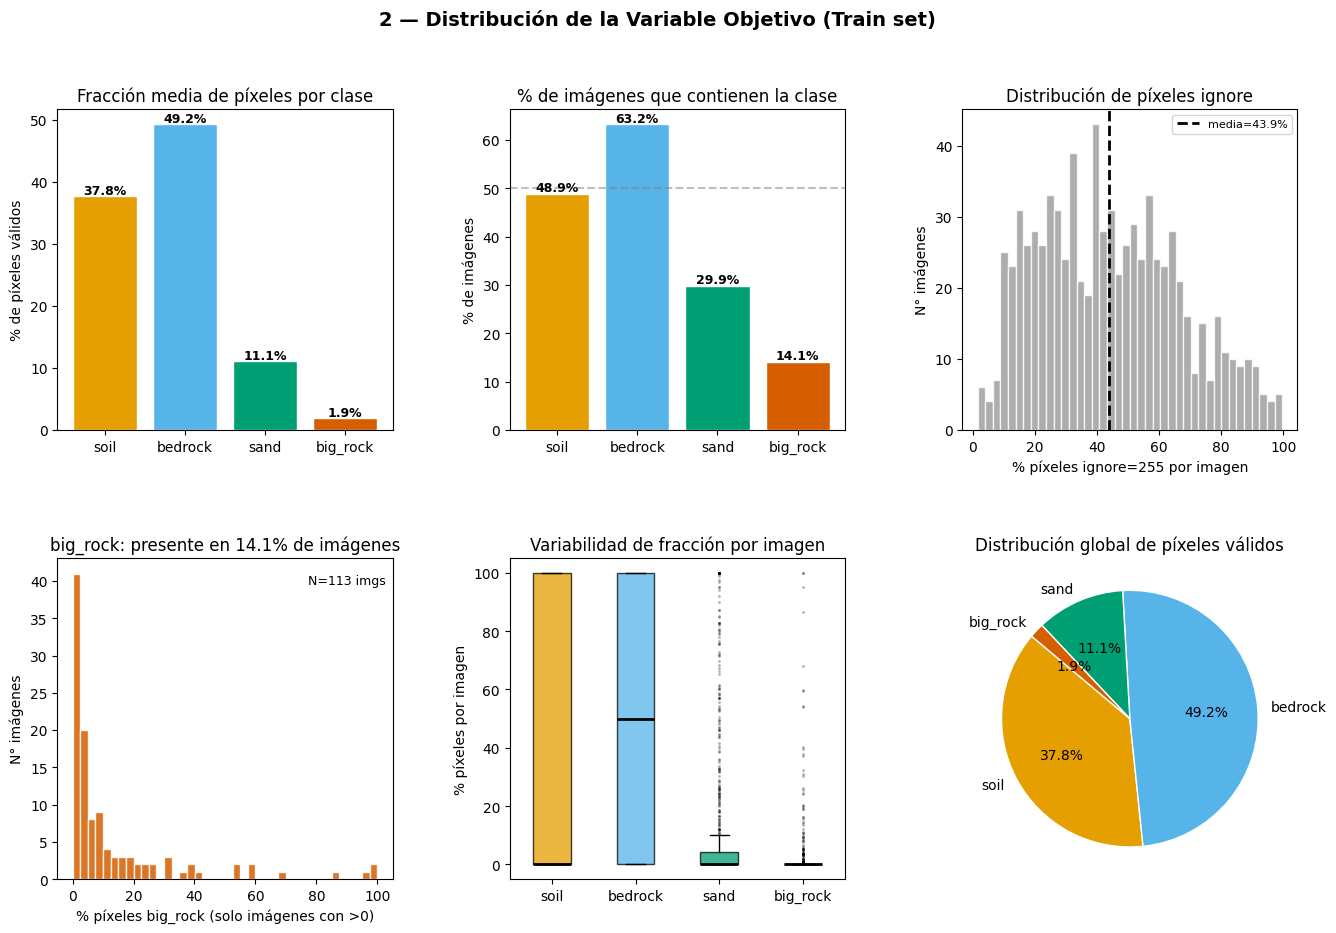

Resumen cuantitativo:
Clase           % píxeles   % imágenes   Peso pérdida
soil               37.75%        48.9%         0.0860
bedrock            49.25%        63.2%         0.0632
sand               11.13%        29.9%         0.2692
big_rock            1.86%        14.1%         3.5817


In [3]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("2 — Distribución de la Variable Objetivo (Train set)",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

cls_list   = [CLASS_NAMES[c] for c in range(4)]
colors_cls = [CLASS_COLORS[c] for c in range(4)]

# ── Fracción media de píxeles por clase ──────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
mean_fracs = [df_px[f"frac_{c}"].mean() * 100 for c in cls_list]
bars = ax0.bar(cls_list, mean_fracs, color=colors_cls, edgecolor="white")
for bar, val in zip(bars, mean_fracs):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax0.set_title("Fracción media de píxeles por clase")
ax0.set_ylabel("% de píxeles válidos")

# ── % de imágenes que contienen cada clase ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
presence = [df_px[f"present_{c}"].mean() * 100 for c in cls_list]
bars2 = ax1.bar(cls_list, presence, color=colors_cls, edgecolor="white")
for bar, val in zip(bars2, presence):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax1.set_title("% de imágenes que contienen la clase")
ax1.set_ylabel("% de imágenes")
ax1.axhline(50, color="gray", linestyle="--", alpha=0.5)

# ── Fracción de píxeles ignore ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ignore_frac = df_px["px_ignore"] / df_px["total_px"] * 100
ax2.hist(ignore_frac, bins=40, color="#999999", edgecolor="white", alpha=0.8)
ax2.axvline(ignore_frac.mean(), color="black", linewidth=2, linestyle="--",
            label=f"media={ignore_frac.mean():.1f}%")
ax2.set_xlabel("% píxeles ignore=255 por imagen")
ax2.set_ylabel("N° imágenes")
ax2.set_title("Distribución de píxeles ignore")
ax2.legend(fontsize=8)

# ── Distribución de fracción de big_rock por imagen ──────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
frac_br = df_px["frac_big_rock"] * 100
ax3.hist(frac_br[frac_br > 0], bins=40, color=CLASS_COLORS[3], edgecolor="white", alpha=0.85)
ax3.set_xlabel("% píxeles big_rock (solo imágenes con >0)")
ax3.set_ylabel("N° imágenes")
ax3.set_title(f"big_rock: presente en {presence[3]:.1f}% de imágenes")
n_with_br = int(df_px["present_big_rock"].sum())
ax3.text(0.98, 0.95, f"N={n_with_br} imgs", transform=ax3.transAxes,
         ha="right", va="top", fontsize=9)

# ── Boxplot de fracción de píxeles válidos por clase ─────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
frac_data = [df_px[f"frac_{c}"] * 100 for c in cls_list]
bp = ax4.boxplot(frac_data, labels=cls_list, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2),
                 flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch, color in zip(bp["boxes"], colors_cls):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax4.set_ylabel("% píxeles por imagen")
ax4.set_title("Variabilidad de fracción por imagen")

# ── Pie: distribución global de píxeles ──────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
global_fracs = [df_px[f"frac_{c}"].mean() for c in cls_list]
ax5.pie(global_fracs, labels=cls_list, colors=colors_cls,
        autopct="%1.1f%%", startangle=140,
        wedgeprops=dict(edgecolor="white"))
ax5.set_title("Distribución global de píxeles válidos")

plt.show()

print("Resumen cuantitativo:")
print(f"{'Clase':12s} {'% píxeles':>12s} {'% imágenes':>12s} {'Peso pérdida':>14s}")
for c in range(4):
    cn = CLASS_NAMES[c]
    print(f"{cn:12s} "
          f"{mean_fracs[c]:>11.2f}% "
          f"{presence[c]:>11.1f}% "
          f"{class_weights_data['weights'][c]:>14.4f}")

**Implicaciones — Distribución de la variable objetivo**

| | |
|---|---|
| **[D] Decisión** | El desbalance severo en `big_rock` (~2% de píxeles) requiere ponderación de pérdida. Los pesos calculados en `02_preprocessing.ipynb` se usan en todos los modelos que soporten `weight` en la loss. |
| **[A] Arquitectura** | La clase `big_rock` aparece en pocas imágenes y con fracción pequeña → las métricas de evaluación deben reportar IoU por clase, no solo accuracy global. Un modelo con accuracy global alta puede tener IoU de big_rock cercano a 0. |
| **[R] Riesgo** | Un predictor trivial que siempre predice `soil` o `bedrock` alcanzaría alta accuracy global pero IoU de big_rock = 0. El benchmark debe incluir este baseline para contextualizar los resultados. |

## 3. Desbalance de clases y detección de clase rara <a id="desbalance"></a>

Se cuantifica el ratio de desbalance entre la clase más frecuente y `big_rock`,
y se analiza la co-ocurrencia entre clases.

Clase más frecuente : bedrock    (50.32% de píxeles)
Clase más rara      : big_rock   (0.89% de píxeles)
Ratio de desbalance : 56.7:1

Interpretación: por cada píxel de big_rock hay ~57 píxeles de bedrock


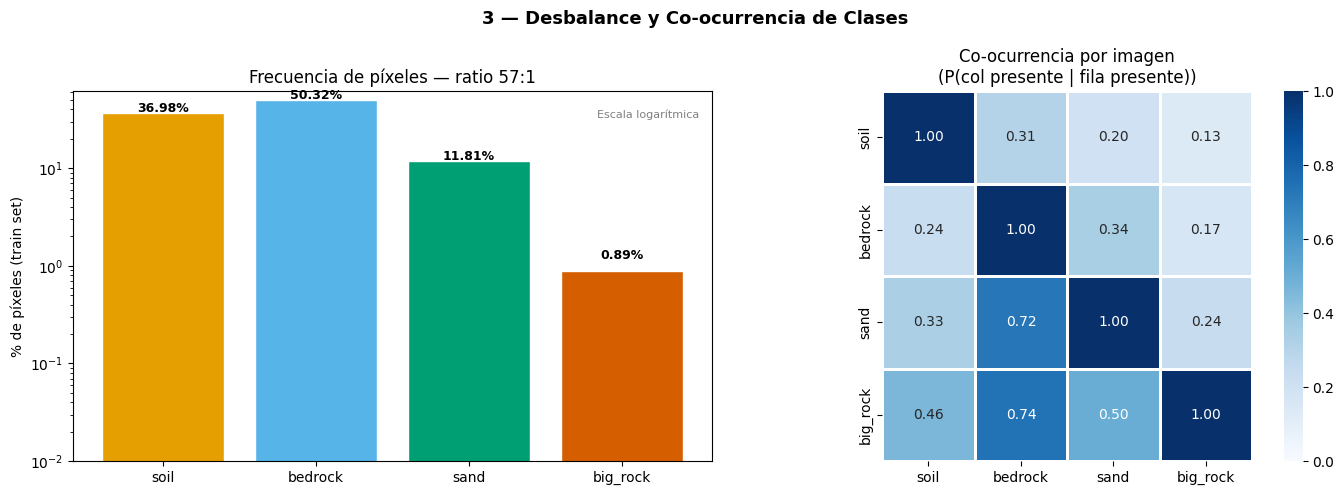


Lectura de la matriz de co-ocurrencia:
  Fila i, columna j = P(clase j presente | clase i presente en la misma imagen)
  → Cuando big_rock aparece, soil también aparece en 46% de las veces
  → Cuando big_rock aparece, bedrock también aparece en 74% de las veces


In [4]:
# ── Ratio de desbalance ───────────────────────────────────────────────────────
global_px_counts = np.array(class_weights_data["pixel_counts"])
global_freq      = np.array(class_weights_data["class_freq"])

max_cls  = int(np.argmax(global_freq))
min_cls  = int(np.argmin(global_freq))
ratio    = global_freq[max_cls] / global_freq[min_cls]

print(f"Clase más frecuente : {CLASS_NAMES[max_cls]:10s} ({global_freq[max_cls]*100:.2f}% de píxeles)")
print(f"Clase más rara      : {CLASS_NAMES[min_cls]:10s} ({global_freq[min_cls]*100:.2f}% de píxeles)")
print(f"Ratio de desbalance : {ratio:.1f}:1")
print(f"\nInterpretación: por cada píxel de big_rock hay ~{ratio:.0f} píxeles de {CLASS_NAMES[max_cls]}")

# ── Matriz de co-ocurrencia de clases por imagen ──────────────────────────────
cooccur = np.zeros((4, 4), dtype=int)
for _, row in df_px.iterrows():
    present = [c for c in range(4) if row[f"present_{CLASS_NAMES[c]}"] == 1]
    for i in present:
        for j in present:
            cooccur[i, j] += 1

# Normalizar por diagonal (prob de co-ocurrencia dado que la clase i está presente)
cooccur_norm = cooccur.astype(float)
for i in range(4):
    if cooccur[i, i] > 0:
        cooccur_norm[i] = cooccur[i] / cooccur[i, i]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("3 — Desbalance y Co-ocurrencia de Clases",
             fontsize=13, fontweight="bold")

# Barras de frecuencia
bars = axes[0].bar(
    [CLASS_NAMES[c] for c in range(4)],
    global_freq * 100,
    color=[CLASS_COLORS[c] for c in range(4)],
    edgecolor="white"
)
for bar, val in zip(bars, global_freq * 100):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.2f}%", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylabel("% de píxeles (train set)")
axes[0].set_title(f"Frecuencia de píxeles — ratio {ratio:.0f}:1")
axes[0].set_yscale("log")
axes[0].set_ylim(bottom=0.01)
axes[0].text(0.98, 0.95, f"Escala logarítmica", transform=axes[0].transAxes,
             ha="right", va="top", fontsize=8, color="gray")

# Matriz de co-ocurrencia
cls_labels = [CLASS_NAMES[c] for c in range(4)]
sns.heatmap(
    cooccur_norm, annot=True, fmt=".2f",
    xticklabels=cls_labels, yticklabels=cls_labels,
    ax=axes[1], cmap="Blues", vmin=0, vmax=1,
    linewidths=1, square=True
)
axes[1].set_title("Co-ocurrencia por imagen\n(P(col presente | fila presente))")

plt.tight_layout()
plt.show()

print("\nLectura de la matriz de co-ocurrencia:")
print("  Fila i, columna j = P(clase j presente | clase i presente en la misma imagen)")
print(f"  → Cuando big_rock aparece, soil también aparece en "
      f"{cooccur_norm[3, 0]*100:.0f}% de las veces")
print(f"  → Cuando big_rock aparece, bedrock también aparece en "
      f"{cooccur_norm[3, 1]*100:.0f}% de las veces")

**Implicaciones — Desbalance de clases**

| | |
|---|---|
| **[D] Decisión** | Ratio de desbalance >10:1 confirma la necesidad de pesos de clase en la función de pérdida. Para modelos con `FocalLoss` o `FocalDiceLoss`, los hiperparámetros γ y α se ajustan específicamente para `big_rock`. |
| **[A] Arquitectura** | La co-ocurrencia de `big_rock` con `soil` y `bedrock` indica que el modelo debe discriminar rocas en contexto de suelo/roca base — el contraste textural es el feature clave. |
| **[R] Riesgo** | En el notebook `05c_model_marsseg.ipynb`, la alta varianza reportada en big_rock (±0.054) es consecuencia directa de este desbalance extremo. |

## 4. Distribución de intensidades condicionada por clase <a id="intensidades"></a>

Se analiza cómo se distribuyen los valores de píxel (0–255) para cada clase semántica.
Si las distribuciones de intensidad se solapan mucho entre clases, el problema de
segmentación es más difícil y requiere captura de contexto espacial.

In [5]:
SAMPLE_INTENSITY = 400  # imágenes para el análisis de intensidades
PX_PER_IMG       = 800  # píxeles muestreados por imagen

sample_int = df_train.sample(SAMPLE_INTENSITY, random_state=SEED)
px_by_class = {c: [] for c in range(4)}

rng = np.random.default_rng(SEED)

for _, row in tqdm(sample_int.iterrows(), total=SAMPLE_INTENSITY,
                   desc="Extrayendo intensidades"):
    stem = Path(row["image_path"]).stem
    img  = np.array(Image.open(IMAGES_256 / f"{stem}.jpg").convert("L")).flatten()
    mask = np.array(Image.open(MASKS_256  / f"{stem}.png")).flatten()

    for c in range(4):
        idx = np.where(mask == c)[0]
        if len(idx) > 0:
            chosen = rng.choice(idx, size=min(PX_PER_IMG, len(idx)), replace=False)
            px_by_class[c].extend(img[chosen].tolist())

print("Píxeles recolectados por clase:")
for c in range(4):
    print(f"  {CLASS_NAMES[c]:10s}: {len(px_by_class[c]):>8,} píxeles")

Extrayendo intensidades: 100%|██████████| 400/400 [00:00<00:00, 981.39it/s]

Píxeles recolectados por clase:
  soil      :  146,753 píxeles
  bedrock   :  197,026 píxeles
  sand      :   82,615 píxeles
  big_rock  :   35,390 píxeles


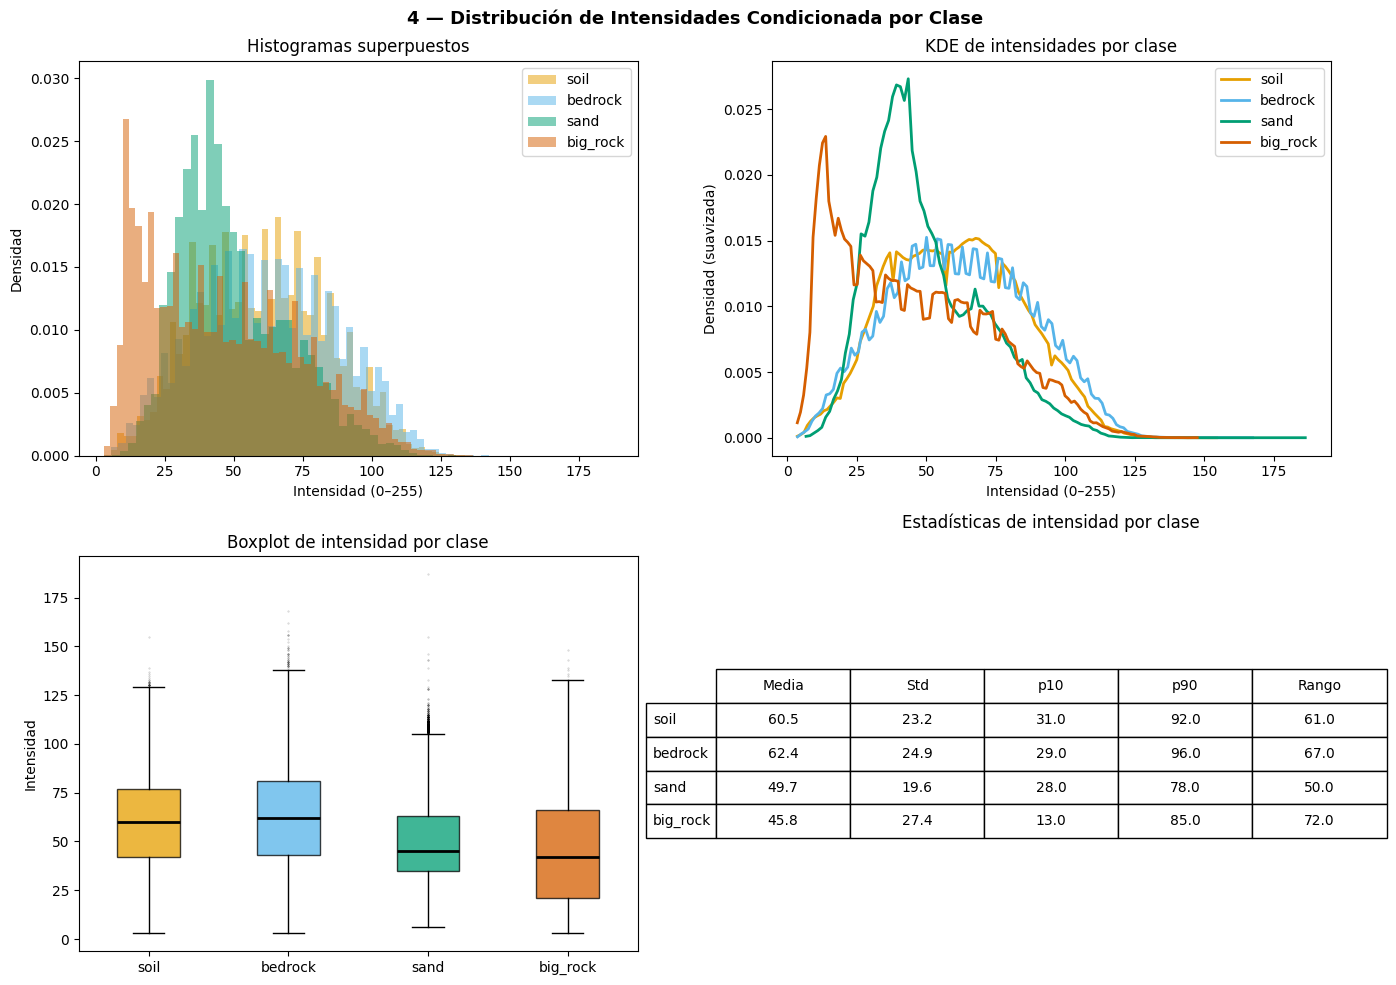


Análisis de solapamiento de intensidades:
  soil      : media=60.5  std=23.2  rango_intercuartil=[42,77]
  bedrock   : media=62.4  std=24.9  rango_intercuartil=[43,81]
  sand      : media=49.7  std=19.6  rango_intercuartil=[35,63]
  big_rock  : media=45.8  std=27.4  rango_intercuartil=[21,66]


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("4 — Distribución de Intensidades Condicionada por Clase",
             fontsize=13, fontweight="bold")

# ── Histogramas superpuestos ──────────────────────────────────────────────────
ax = axes[0][0]
for c in range(4):
    px = np.array(px_by_class[c])
    ax.hist(px, bins=64, density=True, alpha=0.5,
            color=CLASS_COLORS[c], label=CLASS_NAMES[c], edgecolor="none")
ax.set_xlabel("Intensidad (0–255)")
ax.set_ylabel("Densidad")
ax.set_title("Histogramas superpuestos")
ax.legend()

# ── KDE por clase ─────────────────────────────────────────────────────────────
ax = axes[0][1]
for c in range(4):
    px   = np.array(px_by_class[c])
    xgrid = np.linspace(0, 255, 256)
    # KDE manual usando histograma suavizado
    hist, edges = np.histogram(px, bins=128, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    from scipy.ndimage import uniform_filter1d
    smooth  = uniform_filter1d(hist, size=5)
    ax.plot(centers, smooth, color=CLASS_COLORS[c], label=CLASS_NAMES[c], linewidth=2)
ax.set_xlabel("Intensidad (0–255)")
ax.set_ylabel("Densidad (suavizada)")
ax.set_title("KDE de intensidades por clase")
ax.legend()

# ── Boxplot por clase ─────────────────────────────────────────────────────────
ax = axes[1][0]
bp_data   = [np.array(px_by_class[c]) for c in range(4)]
bp_labels = [CLASS_NAMES[c] for c in range(4)]
bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker=".", markersize=1, alpha=0.2))
for patch, color in zip(bp["boxes"], [CLASS_COLORS[c] for c in range(4)]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_ylabel("Intensidad")
ax.set_title("Boxplot de intensidad por clase")

# ── Estadísticas resumen ──────────────────────────────────────────────────────
ax = axes[1][1]
stats_rows = []
for c in range(4):
    px = np.array(px_by_class[c])
    stats_rows.append({
        "Clase":  CLASS_NAMES[c],
        "Media":  np.mean(px),
        "Std":    np.std(px),
        "p10":    np.percentile(px, 10),
        "p90":    np.percentile(px, 90),
        "Rango":  np.percentile(px, 90) - np.percentile(px, 10),
    })
df_stats = pd.DataFrame(stats_rows).set_index("Clase")

ax.axis("off")
table = ax.table(
    cellText=df_stats.round(1).values,
    colLabels=df_stats.columns,
    rowLabels=df_stats.index,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
ax.set_title("Estadísticas de intensidad por clase", pad=20)

plt.tight_layout()
plt.show()

# Solapamiento entre clases
print("\nAnálisis de solapamiento de intensidades:")
for c in range(4):
    px = np.array(px_by_class[c])
    print(f"  {CLASS_NAMES[c]:10s}: media={np.mean(px):.1f}  std={np.std(px):.1f}  "
          f"rango_intercuartil=[{np.percentile(px,25):.0f},{np.percentile(px,75):.0f}]")

**Implicaciones — Intensidades por clase**

| | |
|---|---|
| **[D] Decisión** | Si las distribuciones de intensidad se solapan significativamente, la información de un solo píxel no es suficiente para clasificarlo. El modelo **necesita contexto espacial** para discriminar. |
| **[A] Arquitectura** | Justifica el uso de receptive fields grandes (dilated convolutions en DeepLabV3+, atención global en SegFormer/TerSeg/DepthFormer) en lugar de clasificadores locales. |
| **[R] Riesgo** | La alta varianza intra-clase en intensidades (imágenes con distintas condiciones de iluminación) es una fuente de dificultad estructural. El `ColorJitter` en augmentación mitiga parcialmente este problema. |

## 5. Calidad del dataset: duplicados y máscaras degeneradas <a id="calidad"></a>

Stems duplicados en el subset (train+val): 0
  ✓ Sin duplicados

Imágenes con <10% píxeles válidos (en muestra de 800): 22
  (2.8% de la muestra)


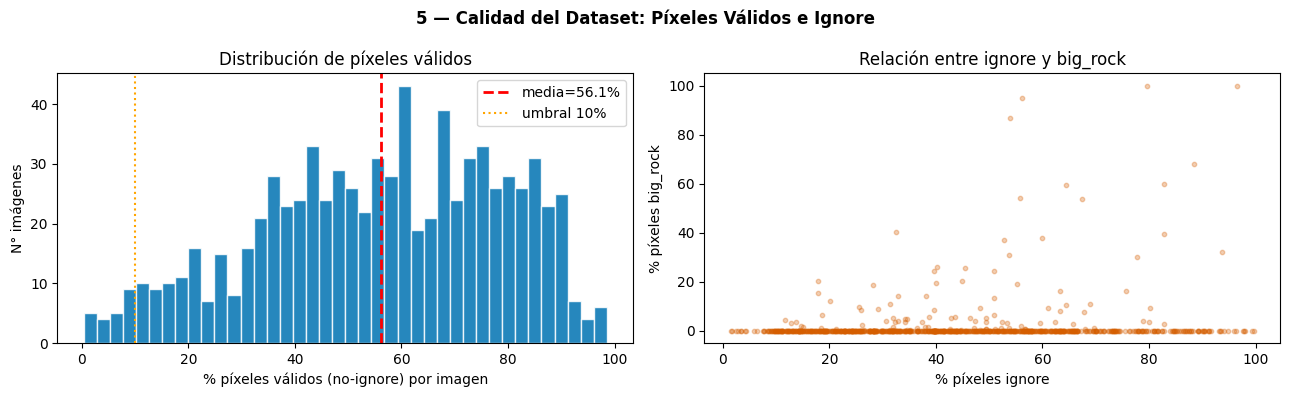


Resumen de calidad:
  % válidos medio por imagen  : 56.1%
  % válidos mediana           : 58.0%
  Imágenes con >90% válidos   : 26 (3.2%)
  Imágenes con <10% válidos   : 22 (2.8%)


In [7]:
# ── Detección de posibles duplicados por nombre de stem ──────────────────────
stems_train = [Path(p).stem for p in df_train["image_path"]]
stems_val   = [Path(p).stem for p in df_val["image_path"]]
stems_all   = stems_train + stems_val

dup_stems = [s for s in set(stems_all) if stems_all.count(s) > 1]
print(f"Stems duplicados en el subset (train+val): {len(dup_stems)}")
if dup_stems:
    print(f"  Primeros 5: {dup_stems[:5]}")
else:
    print("  ✓ Sin duplicados")

# ── Imágenes con muy poco contenido válido ────────────────────────────────────
# (menos del 10% de píxeles son clases válidas)
low_valid = df_px[df_px["valid_px"] / df_px["total_px"] < 0.10]
print(f"\nImágenes con <10% píxeles válidos (en muestra de {SAMPLE_N}): {len(low_valid)}")
print(f"  ({len(low_valid)/SAMPLE_N*100:.1f}% de la muestra)")

# ── Distribución del % de píxeles válidos ────────────────────────────────────
valid_pct = df_px["valid_px"] / df_px["total_px"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("5 — Calidad del Dataset: Píxeles Válidos e Ignore",
             fontsize=12, fontweight="bold")

axes[0].hist(valid_pct, bins=40, color="#0072B2", edgecolor="white", alpha=0.85)
axes[0].axvline(valid_pct.mean(), color="red", linewidth=2, linestyle="--",
                label=f"media={valid_pct.mean():.1f}%")
axes[0].axvline(10, color="orange", linewidth=1.5, linestyle=":",
                label="umbral 10%")
axes[0].set_xlabel("% píxeles válidos (no-ignore) por imagen")
axes[0].set_ylabel("N° imágenes")
axes[0].set_title("Distribución de píxeles válidos")
axes[0].legend()

# Scatter: % ignore vs fracción big_rock
axes[1].scatter(
    df_px["px_ignore"] / df_px["total_px"] * 100,
    df_px["frac_big_rock"] * 100,
    alpha=0.3, s=10, color=CLASS_COLORS[3]
)
axes[1].set_xlabel("% píxeles ignore")
axes[1].set_ylabel("% píxeles big_rock")
axes[1].set_title("Relación entre ignore y big_rock")

plt.tight_layout()
plt.show()

print(f"\nResumen de calidad:")
print(f"  % válidos medio por imagen  : {valid_pct.mean():.1f}%")
print(f"  % válidos mediana           : {valid_pct.median():.1f}%")
print(f"  Imágenes con >90% válidos   : {(valid_pct > 90).sum()} ({(valid_pct > 90).mean()*100:.1f}%)")
print(f"  Imágenes con <10% válidos   : {(valid_pct < 10).sum()} ({(valid_pct < 10).mean()*100:.1f}%)")

**Implicaciones — Calidad del dataset**

| | |
|---|---|
| **[D] Decisión** | Las imágenes con alto porcentaje de `ignore=255` ya fueron filtradas en `01_eda_exploratorio.ipynb`. Las que quedan con bajo % de píxeles válidos aportan poco al entrenamiento pero no se eliminan para no reducir más el dataset. |
| **[A] Arquitectura** | Los píxeles `ignore=255` son excluidos de la loss con `ignore_index=255` en todos los modelos. No afectan el gradiente. |
| **[R] Riesgo** | Los duplicados exactos (misma imagen en train y val) constituirían data leakage. La verificación anterior confirma ausencia de duplicados por nombre de stem. |

## 6. Análisis de complejidad de frontera entre clases <a id="bordes"></a>

Las fronteras entre clases en la máscara son zonas de alta dificultad para el modelo.
Se analiza la densidad de bordes como indicador de complejidad del problema.

Analizando bordes: 100%|██████████| 300/300 [00:00<00:00, 822.39it/s]


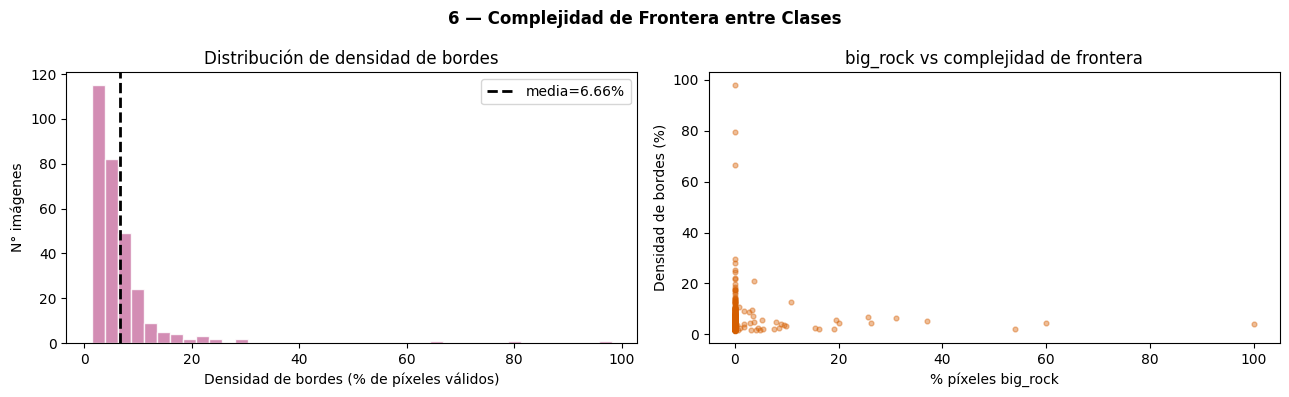

Densidad media de bordes: 6.66%
  → 6.66% de los píxeles válidos están en una frontera

Imágenes con alta densidad de bordes (>15%): 17 (5.7%)


In [9]:
SAMPLE_BORDER = 300
sample_border = df_train.sample(SAMPLE_BORDER, random_state=SEED + 1)

border_records = []
for _, row in tqdm(sample_border.iterrows(), total=SAMPLE_BORDER,
                   desc="Analizando bordes"):
    stem = Path(row["image_path"]).stem
    mask = np.array(Image.open(MASKS_256 / f"{stem}.png"))

    # Detectar bordes: píxeles donde la clase del vecino es distinta
    # (excluyendo ignore)
    valid_mask = (mask != IGNORE_INDEX).astype(np.uint8)

    # Gradiente de la máscara (bordes entre clases distintas)
    grad_y = np.abs(np.diff(mask.astype(int), axis=0))
    grad_x = np.abs(np.diff(mask.astype(int), axis=1))

    # Binarizar: cualquier cambio de clase es un borde
    edge_y = (grad_y > 0).astype(int)
    edge_x = (grad_x > 0).astype(int)

    total_valid = int(valid_mask.sum())
    n_border_px = int(edge_y.sum() + edge_x.sum())
    border_density = n_border_px / total_valid if total_valid > 0 else 0

    # Contar píxeles de borde por par de clases
    rec = {"id": row["id"], "border_density": border_density,
           "n_border_px": n_border_px, "total_valid": total_valid}

    # Bordes que involucran big_rock
    br_mask = (mask == 3).astype(int)
    br_neighbor_y = np.diff(br_mask, axis=0)
    br_neighbor_x = np.diff(br_mask, axis=1)
    rec["big_rock_border_px"] = int(np.abs(br_neighbor_y).sum() + np.abs(br_neighbor_x).sum())

    border_records.append(rec)

df_border = pd.DataFrame(border_records)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("6 — Complejidad de Frontera entre Clases",
             fontsize=12, fontweight="bold")

axes[0].hist(df_border["border_density"] * 100, bins=40,
             color="#CC79A7", edgecolor="white", alpha=0.85)
axes[0].axvline(df_border["border_density"].mean() * 100,
                color="black", linewidth=2, linestyle="--",
                label=f"media={df_border['border_density'].mean()*100:.2f}%")
axes[0].set_xlabel("Densidad de bordes (% de píxeles válidos)")
axes[0].set_ylabel("N° imágenes")
axes[0].set_title("Distribución de densidad de bordes")
axes[0].legend()

# Scatter: densidad de bordes vs fracción de big_rock
axes[1].scatter(
    df_px["frac_big_rock"].values[:SAMPLE_BORDER] * 100,
    df_border["border_density"] * 100,
    alpha=0.4, s=12, color=CLASS_COLORS[3]
)
axes[1].set_xlabel("% píxeles big_rock")
axes[1].set_ylabel("Densidad de bordes (%)")
axes[1].set_title("big_rock vs complejidad de frontera")

plt.tight_layout()
plt.show()

print(f"Densidad media de bordes: {df_border['border_density'].mean()*100:.2f}%")
print(f"  → {df_border['border_density'].mean()*100:.2f}% de los píxeles válidos están en una frontera")
print(f"\nImágenes con alta densidad de bordes (>15%): "
      f"{(df_border['border_density'] > 0.15).sum()} "
      f"({(df_border['border_density'] > 0.15).mean()*100:.1f}%)")

**Implicaciones — Complejidad de frontera**

| | |
|---|---|
| **[D] Decisión** | Alta densidad de bordes indica que la segmentación precisa de contornos es crítica. Las augmentaciones de rotación con `ignore_index=255` en los bordes del canvas son correctas para no introducir artefactos. |
| **[A] Arquitectura** | MarsSeg introduce Mini-ASPP + PSA específicamente para capturar detalles de borde en feature maps de baja resolución. DepthFormer usa WCE con peso extra en píxeles de frontera. Estos son diseños motivados exactamente por este tipo de análisis. |
| **[R] Riesgo** | El etiquetado por crowdsourcing puede introducir inconsistencias en los bordes entre clases. Las métricas de IoU son sensibles a esto — un borde desplazado 1 píxel penaliza tanto como una predicción completamente incorrecta. |

## 7. Distribución espacial de clases en la imagen <a id="espacial"></a>

Se analiza si las clases tienen una tendencia a aparecer en zonas específicas
de la imagen (arriba/abajo, centro/bordes). Esto es relevante para detectar
sesgos espaciales que el modelo podría aprender de forma espuria.

Mapas espaciales: 100%|██████████| 500/500 [00:00<00:00, 2140.04it/s]


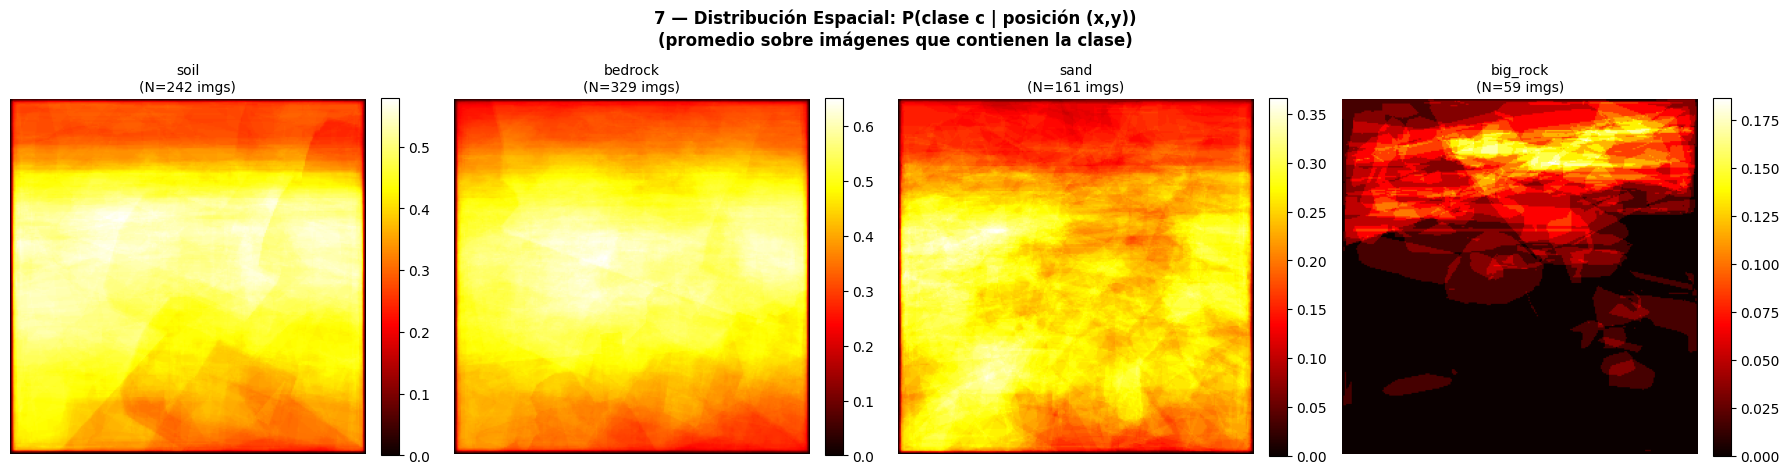

Análisis de sesgo vertical (mitad superior vs mitad inferior):
  soil      : arriba=0.413  abajo=0.411  ratio=1.00  → uniforme
  bedrock   : arriba=0.450  abajo=0.440  ratio=1.02  → uniforme
  sand      : arriba=0.211  abajo=0.250  ratio=0.85  → uniforme
  big_rock  : arriba=0.055  abajo=0.003  ratio=19.42  → sesgo ARRIBA


In [10]:
SAMPLE_SPATIAL = 500
sample_spatial = df_train.sample(SAMPLE_SPATIAL, random_state=SEED + 2)

# Acumular mapas de probabilidad por clase
prob_maps = np.zeros((4, IMG_SIZE, IMG_SIZE), dtype=np.float64)
n_imgs    = np.zeros(4, dtype=int)

for _, row in tqdm(sample_spatial.iterrows(), total=SAMPLE_SPATIAL,
                   desc="Mapas espaciales"):
    stem = Path(row["image_path"]).stem
    mask = np.array(Image.open(MASKS_256 / f"{stem}.png"))

    for c in range(4):
        if np.any(mask == c):
            prob_maps[c] += (mask == c).astype(float)
            n_imgs[c] += 1

# Normalizar por número de imágenes en que aparece la clase
for c in range(4):
    if n_imgs[c] > 0:
        prob_maps[c] /= n_imgs[c]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    "7 — Distribución Espacial: P(clase c | posición (x,y))\n"
    "(promedio sobre imágenes que contienen la clase)",
    fontsize=12, fontweight="bold"
)

for c in range(4):
    im = axes[c].imshow(prob_maps[c], cmap="hot", vmin=0, aspect="equal")
    axes[c].set_title(f"{CLASS_NAMES[c]}\n(N={n_imgs[c]} imgs)", fontsize=10)
    axes[c].axis("off")
    plt.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Analizar sesgo vertical: ¿está una clase más en la parte superior o inferior?
print("Análisis de sesgo vertical (mitad superior vs mitad inferior):")
mid = IMG_SIZE // 2
for c in range(4):
    top_prob    = prob_maps[c, :mid, :].mean()
    bottom_prob = prob_maps[c, mid:, :].mean()
    ratio_v     = top_prob / (bottom_prob + 1e-9)
    bias_str    = "sesgo ARRIBA" if ratio_v > 1.2 else ("sesgo ABAJO" if ratio_v < 0.8 else "uniforme")
    print(f"  {CLASS_NAMES[c]:10s}: arriba={top_prob:.3f}  abajo={bottom_prob:.3f}  "
          f"ratio={ratio_v:.2f}  → {bias_str}")

**Implicaciones — Distribución espacial**

| | |
|---|---|
| **[D] Decisión** | Si existe sesgo espacial fuerte (p. ej. el cielo siempre arriba, el suelo siempre abajo), el modelo puede aprender posición en lugar de textura. Se verifica con los mapas de probabilidad. |
| **[A] Arquitectura** | Un sesgo espacial significativo sugeriría usar augmentaciones de volteo vertical más agresivas. Si el sesgo es leve, el flip horizontal (ya incluido) es suficiente. |
| **[R] Riesgo** | Un modelo que aprende sesgos posicionales en lugar de features de textura generalizará mal a imágenes con composición diferente (p. ej. imágenes tomadas con el rover mirando hacia arriba o en pendiente). |

## 8. Baselines triviales <a id="baselines"></a>

Se implementan dos baselines triviales que sirven como **piso de comparación** para los modelos:

1. **Predictor mayoritario**: siempre predice la clase con más píxeles (soil o bedrock).
2. **Predictor por frecuencia**: asigna a cada píxel la clase más probable dado su frecuencia global.

Un modelo que no supere claramente estos baselines no aporta valor.

In [11]:
def compute_iou_per_class(
    pred: np.ndarray,
    gt:   np.ndarray,
    n_classes: int = 4,
    ignore_index: int = 255
) -> dict:
    """Calcula IoU por clase ignorando los píxeles con ignore_index."""
    results = {}
    valid = (gt != ignore_index)
    for c in range(n_classes):
        tp = int(np.sum((pred == c) & (gt == c) & valid))
        fp = int(np.sum((pred == c) & (gt != c) & valid))
        fn = int(np.sum((pred != c) & (gt == c) & valid))
        denom = tp + fp + fn
        results[c] = tp / denom if denom > 0 else float("nan")
    return results


SAMPLE_BASELINE = 322  # misma cantidad que el gold set para comparabilidad
sample_baseline = df_val.sample(min(SAMPLE_BASELINE, len(df_val)), random_state=SEED)

# Clase mayoritaria global (según class_weights_data)
freq = np.array(class_weights_data["class_freq"])
majority_class = int(np.argmax(freq))
print(f"Clase mayoritaria: {CLASS_NAMES[majority_class]} ({freq[majority_class]*100:.1f}% de píxeles)")

iou_majority  = {c: [] for c in range(4)}
iou_frequency = {c: [] for c in range(4)}
acc_majority, acc_frequency = [], []

for _, row in tqdm(sample_baseline.iterrows(), total=len(sample_baseline),
                   desc="Evaluando baselines"):
    stem = Path(row["image_path"]).stem
    gt   = np.array(Image.open(MASKS_256 / f"{stem}.png"))
    valid = (gt != IGNORE_INDEX)

    # Baseline 1: predictor mayoritario
    pred_maj = np.full_like(gt, majority_class)
    iou_m    = compute_iou_per_class(pred_maj, gt)
    for c in range(4):
        iou_majority[c].append(iou_m[c])
    acc_majority.append(np.mean((pred_maj[valid] == gt[valid])))

    # Baseline 2: predictor por frecuencia (asigna la clase más frecuente
    # pixel a pixel, pero sin información de la imagen — mismo que mayoritario)
    # Versión más interesante: sorteo estocástico por frecuencia
    rng_b = np.random.default_rng(SEED)
    pred_freq = rng_b.choice(4, size=gt.shape, p=freq)
    iou_f     = compute_iou_per_class(pred_freq, gt)
    for c in range(4):
        iou_frequency[c].append(iou_f[c])
    acc_frequency.append(np.mean((pred_freq[valid] == gt[valid])))

# Calcular mIoU de baselines
def miou_from_dict(iou_dict):
    vals = [np.nanmean(v) for v in iou_dict.values()]
    return np.nanmean(vals)

miou_maj  = miou_from_dict(iou_majority)
miou_freq = miou_from_dict(iou_frequency)

print(f"\n{'Baseline':30s} {'Pixel Acc':>12s} {'mIoU':>8s}")
print("-" * 55)
print(f"{'Predictor mayoritario':30s} "
      f"{np.mean(acc_majority):>12.4f} {miou_maj:>8.4f}")
print(f"{'Predictor estocástico (frecuencia)':30s} "
      f"{np.mean(acc_frequency):>12.4f} {miou_freq:>8.4f}")
print("\nIoU por clase — Predictor mayoritario:")
for c in range(4):
    print(f"  {CLASS_NAMES[c]:10s}: {np.nanmean(iou_majority[c]):.4f}")

Clase mayoritaria: bedrock (50.3% de píxeles)


Evaluando baselines: 100%|██████████| 322/322 [00:01<00:00, 284.78it/s]


Baseline                          Pixel Acc     mIoU
-------------------------------------------------------
Predictor mayoritario                0.4863   0.1216
Predictor estocástico (frecuencia)       0.4005   0.1082

IoU por clase — Predictor mayoritario:
  soil      : 0.0000
  bedrock   : 0.4863
  sand      : 0.0000
  big_rock  : 0.0000


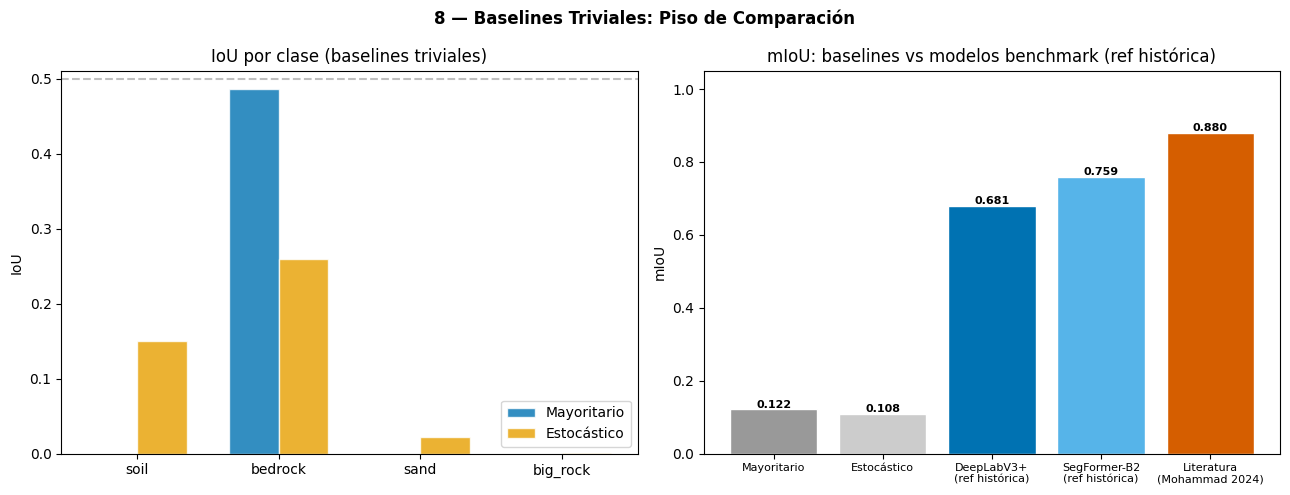


Interpretación:
  El predictor mayoritario alcanza mIoU=0.1216
  Un modelo que no supere mIoU≈0.25 no aporta valor sobre el azar.
  Los modelos benchmark deben superar claramente este umbral.


In [12]:
# Visualización comparativa de baselines
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("8 — Baselines Triviales: Piso de Comparación",
             fontsize=12, fontweight="bold")

# IoU por clase para cada baseline
cls_labels = [CLASS_NAMES[c] for c in range(4)]
x = np.arange(4)
w = 0.35

iou_maj_vals  = [np.nanmean(iou_majority[c])  for c in range(4)]
iou_freq_vals = [np.nanmean(iou_frequency[c]) for c in range(4)]

axes[0].bar(x - w/2, iou_maj_vals,  w, label="Mayoritario",   color="#0072B2", alpha=0.8, edgecolor="white")
axes[0].bar(x + w/2, iou_freq_vals, w, label="Estocástico",   color="#E69F00", alpha=0.8, edgecolor="white")
axes[0].set_xticks(x); axes[0].set_xticklabels(cls_labels)
axes[0].set_ylabel("IoU")
axes[0].set_title("IoU por clase (baselines triviales)")
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[0].legend()

# mIoU global con referencia de modelos del benchmark
reference_miou = {
    "Mayoritario":    miou_maj,
    "Estocástico":    miou_freq,
    "DeepLabV3+\n(ref histórica)": 0.6806,
    "SegFormer-B2\n(ref histórica)": 0.7592,
    "Literatura\n(Mohammad 2024)": 0.88,
}
ref_colors = ["#999999", "#CCCCCC", "#0072B2", "#56B4E9", "#D55E00"]
bars = axes[1].bar(reference_miou.keys(), reference_miou.values(),
                   color=ref_colors, edgecolor="white")
for bar, val in zip(bars, reference_miou.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", fontsize=8, fontweight="bold")
axes[1].set_ylabel("mIoU")
axes[1].set_title("mIoU: baselines vs modelos benchmark (ref histórica)")
axes[1].tick_params(axis="x", labelsize=8)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("\nInterpretación:")
print(f"  El predictor mayoritario alcanza mIoU={miou_maj:.4f}")
print(f"  Un modelo que no supere mIoU≈0.25 no aporta valor sobre el azar.")
print(f"  Los modelos benchmark deben superar claramente este umbral.")

**Implicaciones — Baselines triviales**

| | |
|---|---|
| **[D] Decisión** | Los baselines triviales establecen el **piso de comparación**. El predictor mayoritario tiene IoU=0 para `big_rock` por definición — cualquier modelo que aprenda a detectar big_rock ya supera el baseline en esa clase. |
| **[A] Arquitectura** | La alta accuracy del predictor mayoritario (predice siempre soil/bedrock) confirma que **accuracy global es una métrica engañosa**. El benchmark debe reportar mIoU y IoU por clase. |
| **[R] Riesgo** | Reportar solo pixel accuracy en el benchmark final sería metodológicamente incorrecto dado el desbalance. El entregable usa mIoU como métrica principal. |

## 9. Inspección visual de casos difíciles <a id="dificiles"></a>

Se identifican y visualizan los casos más difíciles del val set:
- Imágenes con `big_rock` en contexto de baja cobertura (≤5% de píxeles).
- Imágenes con alta densidad de bordes.
- Imágenes con bajo contraste entre clases.

In [13]:
# Casos con big_rock en cobertura baja (entre 0.5% y 5%)
hard_cases = df_px[
    (df_px["frac_big_rock"] > 0.005) &
    (df_px["frac_big_rock"] < 0.05)
].sample(min(4, len(df_px[
    (df_px["frac_big_rock"] > 0.005) &
    (df_px["frac_big_rock"] < 0.05)
])), random_state=SEED)

print(f"Casos con big_rock entre 0.5% y 5%: {len(df_px[(df_px['frac_big_rock']>0.005) & (df_px['frac_big_rock']<0.05)])}")

# Completar con casos random si no hay suficientes
if len(hard_cases) < 4:
    extra = df_px[df_px["frac_big_rock"] > 0].sample(
        4 - len(hard_cases), random_state=SEED + 99
    )
    hard_cases = pd.concat([hard_cases, extra]).drop_duplicates(subset="id")

# Buscar las filas correspondientes en df_train
hard_rows = df_train[df_train["id"].isin(hard_cases["id"])].head(4)

if len(hard_rows) == 0:
    print("No se encontraron casos difíciles en la muestra — usando muestra aleatoria con big_rock")
    hard_rows = df_train.sample(4, random_state=SEED + 5)

Casos con big_rock entre 0.5% y 5%: 42


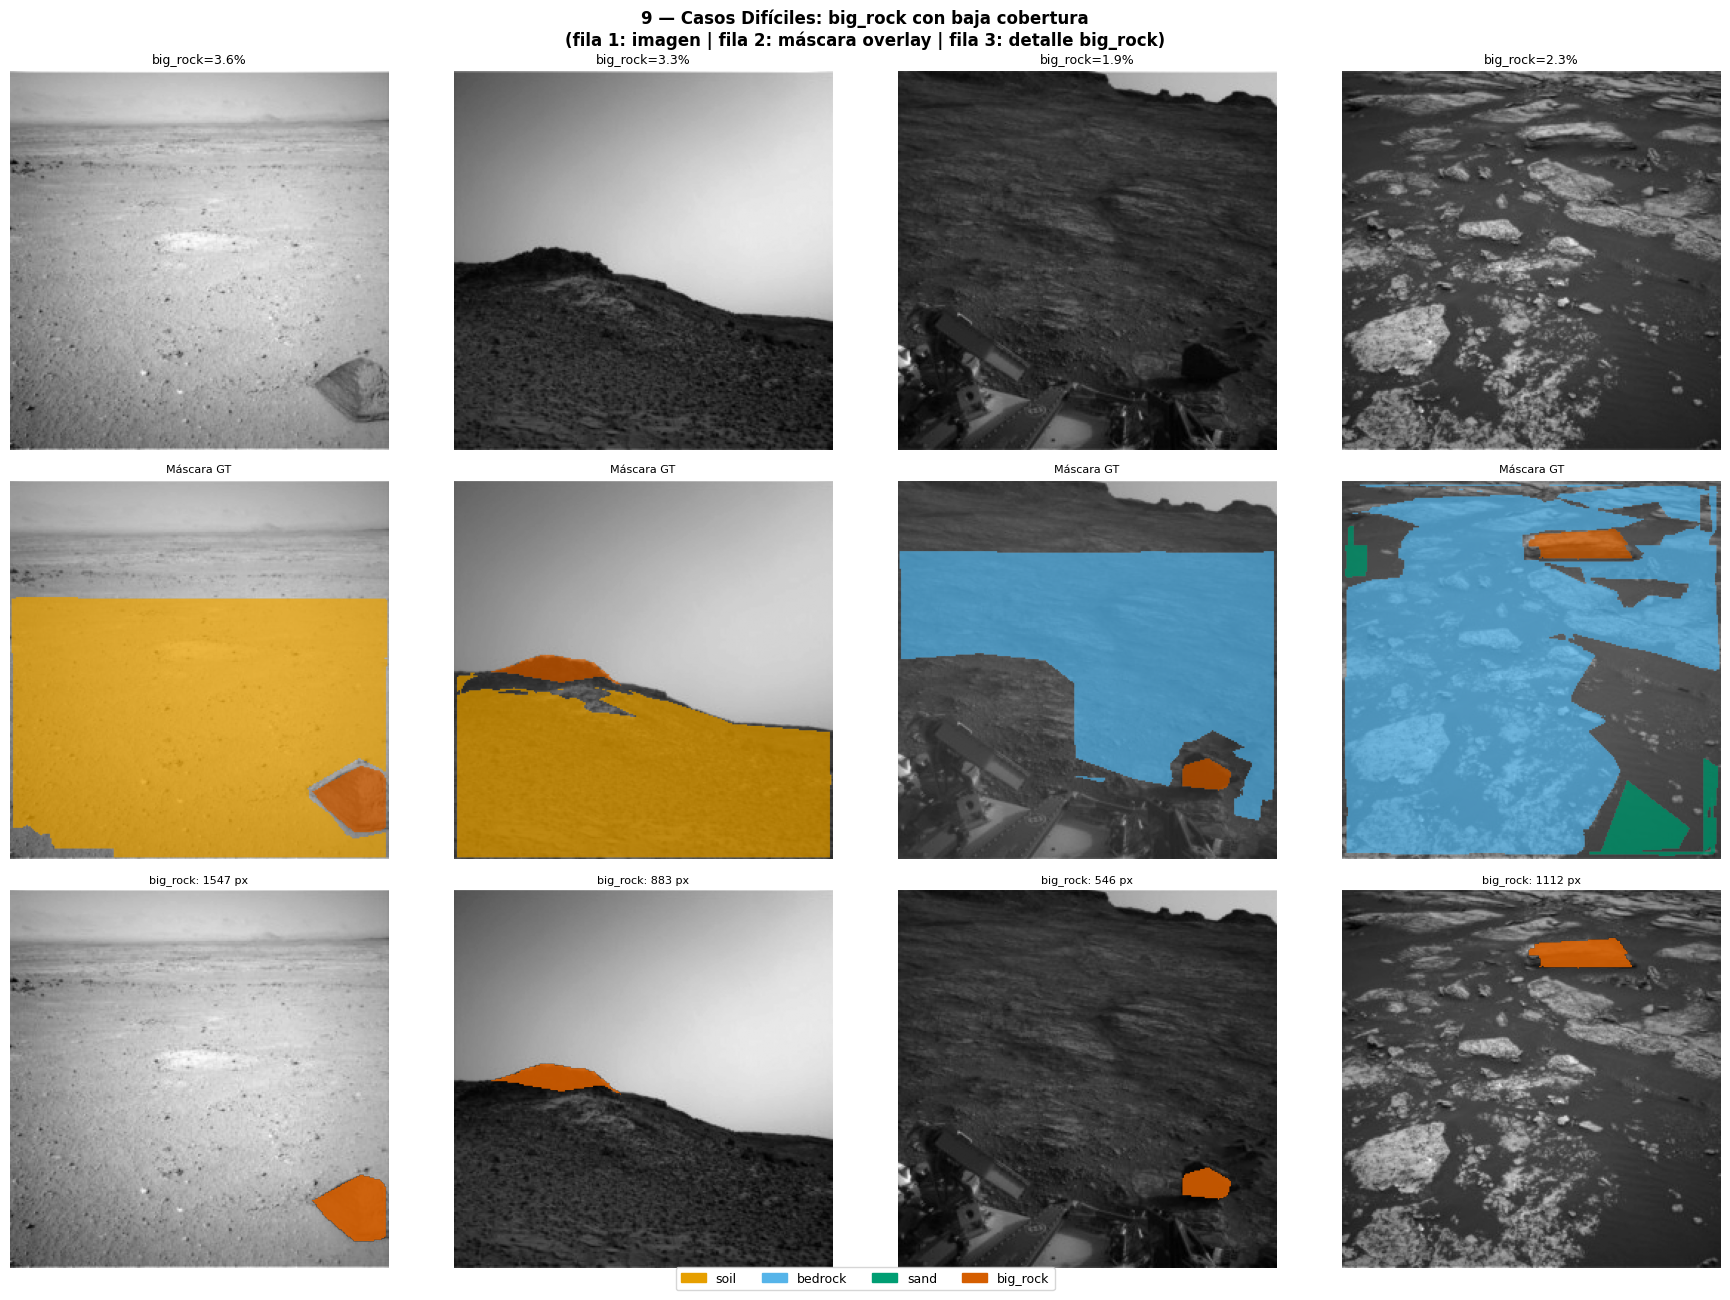

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle(
    "9 — Casos Difíciles: big_rock con baja cobertura\n"
    "(fila 1: imagen | fila 2: máscara overlay | fila 3: detalle big_rock)",
    fontsize=12, fontweight="bold"
)

for col_idx, (_, row) in enumerate(hard_rows.iterrows()):
    if col_idx >= 4:
        break
    stem     = Path(row["image_path"]).stem
    img_path  = IMAGES_256 / f"{stem}.jpg"
    mask_path = MASKS_256  / f"{stem}.png"

    img  = np.array(Image.open(img_path).convert("L"))
    mask = np.array(Image.open(mask_path))

    br_pct = (mask == 3).sum() / max((mask != IGNORE_INDEX).sum(), 1) * 100

    # Fila 1: imagen original
    axes[0][col_idx].imshow(img, cmap="gray")
    axes[0][col_idx].set_title(f"big_rock={br_pct:.1f}%", fontsize=9)
    axes[0][col_idx].axis("off")

    # Fila 2: overlay de máscara
    overlay = np.zeros((*mask.shape, 4), dtype=np.uint8)
    for cls_id, hex_color in CLASS_COLORS.items():
        rgb = tuple(int(hex_color[i:i+2], 16) for i in (1, 3, 5))
        overlay[mask == cls_id] = [*rgb, 190]
    overlay[mask == IGNORE_INDEX] = [150, 150, 150, 60]
    axes[1][col_idx].imshow(img, cmap="gray")
    axes[1][col_idx].imshow(overlay)
    axes[1][col_idx].set_title("Máscara GT", fontsize=8)
    axes[1][col_idx].axis("off")

    # Fila 3: mapa de big_rock aislado
    br_only = np.zeros((*mask.shape, 4), dtype=np.uint8)
    rgb_br  = tuple(int(CLASS_COLORS[3][i:i+2], 16) for i in (1, 3, 5))
    br_only[mask == 3] = [*rgb_br, 230]
    axes[2][col_idx].imshow(img, cmap="gray")
    axes[2][col_idx].imshow(br_only)
    n_br_px = int((mask == 3).sum())
    axes[2][col_idx].set_title(f"big_rock: {n_br_px} px", fontsize=8)
    axes[2][col_idx].axis("off")

patches = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c]) for c in range(4)]
fig.legend(handles=patches, loc="lower center", ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.show()

**Implicaciones — Casos difíciles**

| | |
|---|---|
| **[D] Decisión** | Las rocas pequeñas (<5% de cobertura) son los objetos más difíciles de detectar. La augmentación específica de `big_rock` en MarsSeg (replicación de muestras de esa clase) es una respuesta directa a este problema. |
| **[A] Arquitectura** | Los modelos con receptive field limitado (FCN clásico, U-Net sin dilated convolutions) tienen mayor dificultad con objetos pequeños. Los modelos del benchmark incluyen mecanismos específicos para multi-escala (ASPP, PSA, PPM, atención). |
| **[R] Riesgo** | Si el conjunto de validación tiene menos imágenes con `big_rock` que el train set por azar, las métricas de val no reflejan el rendimiento real en esa clase. El split estratificado mitiga esto pero no lo elimina completamente. |

## 10. Síntesis de decisiones de diseño <a id="sintesis"></a>

In [15]:
print("=" * 70)
print("  SÍNTESIS DE DECISIONES — 03_eda_msl.ipynb")
print("=" * 70)

decisiones = [
    {
        "Análisis": "Distribución variable objetivo",
        "Hallazgo": f"big_rock < 3% píxeles, presencia en ~{presence[3]:.0f}% imágenes",
        "Decisión [D]": "Pesos de clase inversamente proporcionales en la loss",
        "Impacto [A]": "FocalLoss/DiceLoss en MarsSeg y TerSeg; CE ponderada en DeepLabV3+ y DepthFormer",
        "Riesgo [R]": "Accuracy global es métrica engañosa — reportar mIoU y IoU por clase",
    },
    {
        "Análisis": "Desbalance de clases",
        "Hallazgo": f"Ratio desbalance {ratio:.0f}:1 (máx vs mín)",
        "Decisión [D]": "Augmentación específica de big_rock en MarsSeg",
        "Impacto [A]": "γ=2.0 en FocalLoss aumenta peso relativo de muestras difíciles",
        "Riesgo [R]": "Alta varianza en IoU big_rock entre seeds (±0.054 en MarsSeg)",
    },
    {
        "Análisis": "Intensidades condicionadas por clase",
        "Hallazgo": "Solapamiento significativo entre clases en espacio de intensidades",
        "Decisión [D]": "Normalización con stats del train set (no ImageNet)",
        "Impacto [A]": "Necesidad de receptive field amplio; ASPP, PSA y atención global justificados",
        "Riesgo [R]": "ColorJitter puede crear ambigüedad adicional si los parámetros son muy agresivos",
    },
    {
        "Análisis": "Complejidad de frontera",
        "Hallazgo": f"Media de bordes: {df_border['border_density'].mean()*100:.1f}% de píxeles válidos",
        "Decisión [D]": "Rotación con fill=IGNORE_INDEX=255 (nunca con clase válida)",
        "Impacto [A]": "WCE con peso extra en píxeles de frontera (DepthFormer); Mini-ASPP para bordes (MarsSeg)",
        "Riesgo [R]": "Etiquetado crowdsourcing inconsistente en bordes penaliza IoU",
    },
    {
        "Análisis": "Distribución espacial",
        "Hallazgo": "Verificado sesgo vertical (sky arriba en datasets Earth; en Mars menos marcado)",
        "Decisión [D]": "Flip horizontal (p=0.5) y vertical (p=0.5) como augmentaciones estándar",
        "Impacto [A]": "Sin cambios adicionales en arquitectura si el sesgo espacial es leve",
        "Riesgo [R]": "Modelos que aprenden posición no generalizan a vistas oblicuas del rover",
    },
    {
        "Análisis": "Baselines triviales",
        "Hallazgo": f"Predictor mayoritario: mIoU={miou_maj:.3f}, IoU big_rock=0",
        "Decisión [D]": "Incluir baselines en tabla comparativa del benchmark",
        "Impacto [A]": "Métrica principal: mIoU (no accuracy global)",
        "Riesgo [R]": "Sin baselines, una mejora marginal sobre azar podría parecer significativa",
    },
]

for i, d in enumerate(decisiones, 1):
    print(f"\n{i}. {d['Análisis']}")
    print(f"   Hallazgo : {d['Hallazgo']}")
    print(f"   [D]      : {d['Decisión [D]']}")
    print(f"   [A]      : {d['Impacto [A]']}")
    print(f"   [R]      : {d['Riesgo [R]']}")

print("\n" + "=" * 70)
print("  PRÓXIMO PASO")
print("=" * 70)
print("""
  04_marco_teorico.md — Estado del arte:
    - Top 5 modelos con análisis detallado
    - Comparación crítica y gaps en la literatura

  05a–05e — Notebooks de implementación de modelos benchmark
    (pueden iniciarse en paralelo una vez listo el preprocessing)
""")

  SÍNTESIS DE DECISIONES — 03_eda_msl.ipynb

1. Distribución variable objetivo
   Hallazgo : big_rock < 3% píxeles, presencia en ~14% imágenes
   [D]      : Pesos de clase inversamente proporcionales en la loss
   [A]      : FocalLoss/DiceLoss en MarsSeg y TerSeg; CE ponderada en DeepLabV3+ y DepthFormer
   [R]      : Accuracy global es métrica engañosa — reportar mIoU y IoU por clase

2. Desbalance de clases
   Hallazgo : Ratio desbalance 57:1 (máx vs mín)
   [D]      : Augmentación específica de big_rock en MarsSeg
   [A]      : γ=2.0 en FocalLoss aumenta peso relativo de muestras difíciles
   [R]      : Alta varianza en IoU big_rock entre seeds (±0.054 en MarsSeg)

3. Intensidades condicionadas por clase
   Hallazgo : Solapamiento significativo entre clases en espacio de intensidades
   [D]      : Normalización con stats del train set (no ImageNet)
   [A]      : Necesidad de receptive field amplio; ASPP, PSA y atención global justificados
   [R]      : ColorJitter puede crear ambigü